<a href="https://colab.research.google.com/github/meti-creator/datamanupilation/blob/main/preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
df=pd.read_csv("/content/sample_data/3) Sentiment dataset.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
df.dtypes

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
Text,object
Sentiment,object
Timestamp,object
User,object
Platform,object
Hashtags,object
Retweets,float64
Likes,float64


In [ ]:
#lets change the timestamp dtype to date_time
df['Timestamp']=pd.to_datetime(df['Timestamp'])

In [ ]:
#remove repeated column

df.drop('Day',axis=1,inplace=True)



In [ ]:
df.head()

,Unnamed: 0.1,Text,Sentiment,Timestamp,Platform,Hashtags,Retweets,Likes,Country
0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,Twitter,#Nature #Park,15.0,30.0,USA
1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,Instagram,#Fitness #Workout,20.0,40.0,USA
3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,Facebook,#Travel #Adventure,8.0,15.0,UK
4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,Instagram,#Cooking #Food,12.0,25.0,Australia


In [ ]:
df['Text'] = df['Text'].str.encode('ascii', 'ignore').str.decode('ascii')

In [ ]:
#incase there is capitalization problem
df['Text']=df['Text'].str.lower()
df['Sentiment']=df['Sentiment'].str.lower()

In [ ]:
df.head()

,Unnamed: 0.1,Text,Sentiment,Timestamp,Platform,Hashtags,Retweets,Likes,Country
0,0,enjoying a beautiful day at the park! ...,positive,2023-01-15 12:30:00,Twitter,#Nature #Park,15.0,30.0,USA
1,1,traffic was terrible this morning. ...,negative,2023-01-15 08:45:00,Twitter,#Traffic #Morning,5.0,10.0,Canada
2,2,just finished an amazing workout! ...,positive,2023-01-15 15:45:00,Instagram,#Fitness #Workout,20.0,40.0,USA
3,3,excited about the upcoming weekend getaway! ...,positive,2023-01-15 18:20:00,Facebook,#Travel #Adventure,8.0,15.0,UK
4,4,trying out a new recipe for dinner tonight. ...,neutral,2023-01-15 19:55:00,Instagram,#Cooking #Food,12.0,25.0,Australia


In [ ]:
#check if there is null values
df.isna().sum()
df.dropna(inplace=True)
df.drop('Unnamed: 0.1',axis =1 ,inplace=True)

In [ ]:
#number of unique values
len(df['Sentiment'].unique())

279

In [ ]:
# Strip whitespace from columns to avoid duplicate labels like ' Twitter' and 'Twitter'
df['Sentiment'] = df['Sentiment'].str.strip()
df['Platform'] = df['Platform'].str.strip()

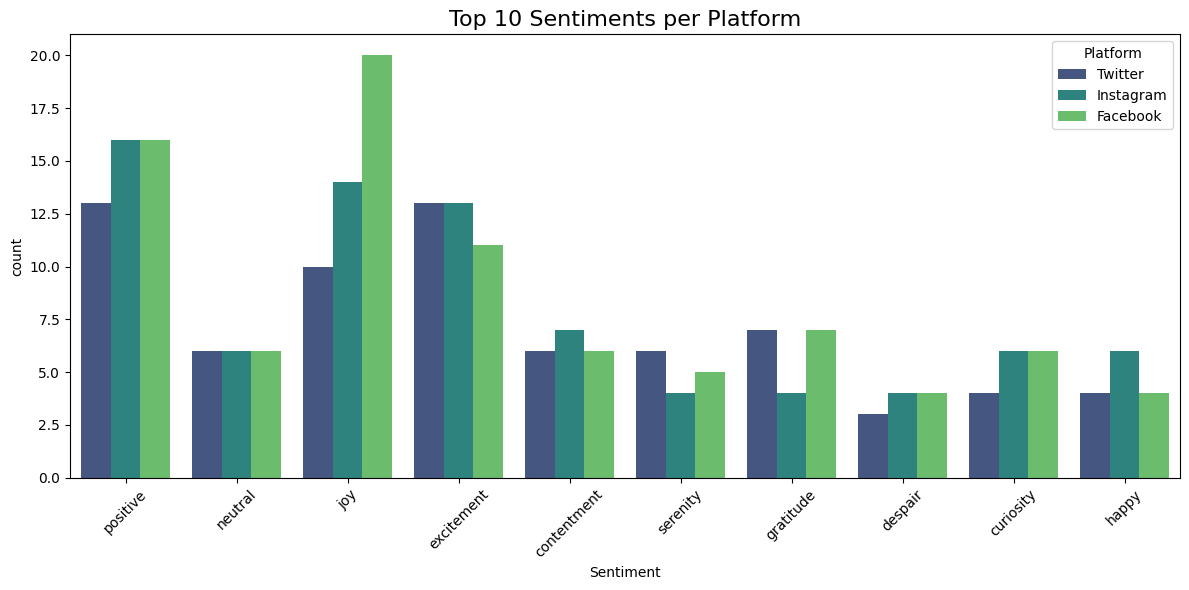

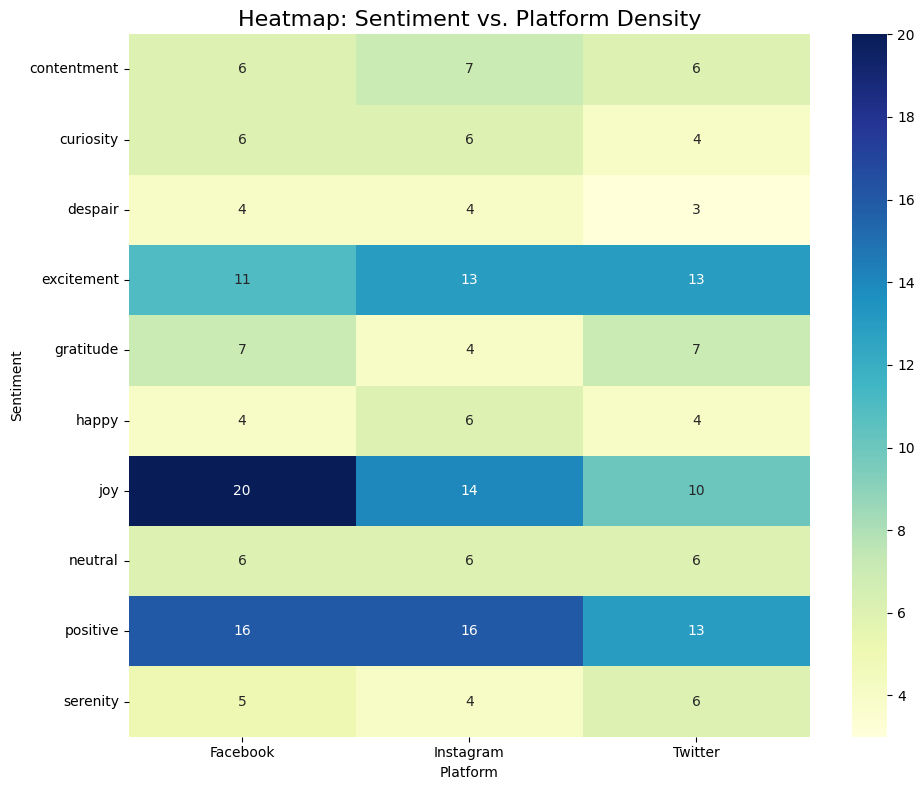

In [ ]:
#lets visualize the relationship between sentiment and platform

# 2. Select Top 10 Sentiments for Clarity
top_10 = df['Sentiment'].value_counts().nlargest(10).index
df_filtered = df[df['Sentiment'].isin(top_10)]


plt.figure(figsize=(12, 6))
sns.countplot(data=df_filtered, x='Sentiment', hue='Platform', palette='viridis')
plt.title('Top 10 Sentiments per Platform', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sentiment_platform_bar.png')
plt.show()

plt.figure(figsize=(10, 8))
# Create a cross-tabulation table
cross_tab = pd.crosstab(df_filtered['Sentiment'], df_filtered['Platform'])
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap: Sentiment vs. Platform Density', fontsize=16)
plt.tight_layout()
plt.savefig('sentiment_platform_heatmap.png')
plt.show()

Sentiment Trends: The data is overwhelmingly Positive, with "Joy" and "Excitement" being the most frequent labels. This indicates a "positive bias" that your model will need to account for.
Platform Personalities:
Facebook: The primary home for "Joy"it has the highest concentration of high-energy positive posts.
Instagram: Focused on "Positivity" and| "Contentment," showing a very steady and upbeat profile.
Twitter: More diverse, featuring higher levels of "Neutral" and "Serenity" labels, likely due to its role in sharing news and information.

Actionable Insight: The Platform column is a strong predictor. Because sentiments are not distributed equally (e.g., "Joy" is 2x more likely on Facebook than Twitter), including the platform as a feature will significantly improve your model's accuracy.

In [ ]:
#map the sentiment to three groups so that it gets easier for model to predict
sentiment_map = {
    # Positive Group
    'Positive': 'Positive', 'Joy': 'Positive', 'Excitement': 'Positive',
    'Happy': 'Positive', 'Contentment': 'Positive', 'Gratitude': 'Positive',
    'Serenity': 'Positive', 'Admiration': 'Positive', 'Awe': 'Positive',

    # Negative Group
    'Negative': 'Negative', 'Anger': 'Negative', 'Fear': 'Negative',
    'Sadness': 'Negative', 'Disgust': 'Negative', 'Frustration': 'Negative',
    'Anxiety': 'Negative', 'Bitterness': 'Negative', 'Despair': 'Negative',

    # Neutral Group
    'Neutral': 'Neutral', 'Ambivalence': 'Neutral', 'Curiosity': 'Neutral',
    'Pensive': 'Neutral', 'Indifference': 'Neutral'
}

df['Sentiment_Group'] = df['Sentiment'].map(lambda x: sentiment_map.get(x, 'Neutral'))

print("New grouped distribution:")
print(df['Sentiment_Group'].value_counts())

New grouped distribution:
Sentiment_Group
Neutral    732
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. Load and Clean

# 2. Define your Groups (All keys are lowercase now)
sentiment_map = {
    # Positive Group
    'positive': 'Positive', 'joy': 'Positive', 'excitement': 'Positive',
    'happy': 'Positive', 'happiness': 'Positive', 'contentment': 'Positive',
    'gratitude': 'Positive', 'serenity': 'Positive', 'love': 'Positive',
    'admiration': 'Positive', 'awe': 'Positive', 'enjoyment': 'Positive',

    # Negative Group
    'negative': 'Negative', 'anger': 'Negative', 'fear': 'Negative',
    'sadness': 'Negative', 'disgust': 'Negative', 'frustration': 'Negative',
    'anxiety': 'Negative', 'bitterness': 'Negative', 'despair': 'Negative',
    'disappointed': 'Negative',

    # Neutral Group
    'neutral': 'Neutral', 'ambivalence': 'Neutral', 'curiosity': 'Neutral',
    'pensive': 'Neutral', 'indifference': 'Neutral', 'surprise': 'Neutral'
}

# 3. Apply the Mapping
# If it's not in our map, we'll keep it as 'Neutral' for now
df['Sentiment_Group'] = df['Sentiment'].map(sentiment_map).fillna('Neutral')

# 4. Check the results again
print("New grouped distribution:")
print(df['Sentiment_Group'].value_counts())

New grouped distribution:
Sentiment_Group
Neutral     476
Positive    215
Negative     41
Name: count, dtype: int64


In [ ]:
df

,Text,Sentiment,Timestamp,Platform,Hashtags,Retweets,Likes,Country,Sentiment_Group
0,enjoying a beautiful day at the park! ...,positive,2023-01-15 12:30:00,Twitter,#Nature #Park,15.0,30.0,USA,Positive
1,traffic was terrible this morning. ...,negative,2023-01-15 08:45:00,Twitter,#Traffic #Morning,5.0,10.0,Canada,Negative
2,just finished an amazing workout! ...,positive,2023-01-15 15:45:00,Instagram,#Fitness #Workout,20.0,40.0,USA,Positive
3,excited about the upcoming weekend getaway! ...,positive,2023-01-15 18:20:00,Facebook,#Travel #Adventure,8.0,15.0,UK,Positive
4,trying out a new recipe for dinner tonight. ...,neutral,2023-01-15 19:55:00,Instagram,#Cooking #Food,12.0,25.0,Australia,Neutral
...,...,...,...,...,...,...,...,...,...
727,collaborating on a science project that receiv...,happy,2017-08-18 18:20:00,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,Positive
728,attending a surprise birthday party organized ...,happy,2018-06-22 14:15:00,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,Positive
729,successfully fundraising for a school charity ...,happy,2019-04-05 17:30:00,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,Positive
730,"participating in a multicultural festival, cel...",happy,2020-02-29 20:45:00,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,Positive
